# Male vs Female Author Bias Comparison

This notebook excludes `submissive` from all tables and graphs.

$$\Delta = \text{Male\_Author\_Bias} - \text{Female\_Author\_Bias}$$

In [1]:
import json
from pathlib import Path
import pandas as pd

comparison_path = Path('outputs') / 'task_male_female_bias_comparison.csv'
meta_path = Path('outputs') / 'task_male_female_corpus_meta.json'

df = pd.read_csv(comparison_path)
df = df[df['Attribute_Word'].str.lower() != 'submissive'].copy()
meta = json.loads(meta_path.read_text(encoding='utf-8'))

print('Female books downloaded:', meta.get('female_books_downloaded', 'N/A'))
print('Male books downloaded:', meta.get('male_books_downloaded', 'N/A'))
print('Female download dir:', meta.get('female_download_dir', 'N/A'))
print('Male download dir:', meta.get('male_download_dir', 'N/A'))
print('Rows in comparison table (without submissive):', len(df))
print('Mean |Delta|:', round(df['Delta'].abs().mean(), 6))
print('Max |Delta|:', round(df['Delta'].abs().max(), 6))

Female books downloaded: 15
Male books downloaded: 15
Female download dir: outputs\male_female_downloaded_books\female
Male download dir: outputs\male_female_downloaded_books\male
Rows in comparison table (without submissive): 24
Mean |Delta|: 0.011365
Max |Delta|: 0.03313


In [2]:
top_delta = df.reindex(df['Delta'].abs().sort_values(ascending=False).index).head(15)
top_delta

,Attribute_Word,Category,Female_Author_Bias,Male_Author_Bias,Delta
1,manager,professions,-0.038637,-0.005507,0.033130
2,nurse,professions,-0.070489,-0.101362,-0.030873
3,strong,stereotype_traits,-0.006082,0.020051,0.026133
4,imagination,arts,-0.009156,0.012821,0.021977
5,art,arts,-0.005126,0.015841,0.020967
6,poetry,arts,-0.019708,-0.000633,0.019075
7,artist,professions,-0.001087,0.016903,0.017990
8,painting,arts,0.004053,-0.008403,-0.012456
9,beauty,arts,-0.070752,-0.081704,-0.010952
10,lawyer,professions,0.025328,0.014418,-0.010911


In [3]:
try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

def plot_top_overall_delta(frame, top_n=15):
    if plt is None:
        print('matplotlib is not available; cannot render charts.')
        return
    top = frame.reindex(frame['Delta'].abs().sort_values(ascending=False).index).head(top_n)
    labels = [f"{r.Category}:{r.Attribute_Word}" for r in top.itertuples(index=False)]
    values = top['Delta'].tolist()
    colors = ['#1f77b4' if v >= 0 else '#d62728' for v in values]
    plt.figure(figsize=(14, 5))
    plt.bar(labels, values, color=colors)
    plt.axhline(0.0, color='black', linewidth=1)
    plt.title(f'Top {top_n} |Delta| Across All Categories')
    plt.ylabel('Delta (Male_Author_Bias - Female_Author_Bias)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_category_individual_bias(frame, category):
    if plt is None:
        print('matplotlib is not available; cannot render charts.')
        return
    cdf = frame[frame['Category'] == category].copy()
    cdf = cdf.reindex(cdf['Delta'].abs().sort_values(ascending=False).index)
    labels = cdf['Attribute_Word'].tolist()
    female_vals = cdf['Female_Author_Bias'].tolist()
    male_vals = cdf['Male_Author_Bias'].tolist()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    female_colors = ['#1f77b4' if v >= 0 else '#d62728' for v in female_vals]
    axes[0].bar(labels, female_vals, color=female_colors)
    axes[0].axhline(0.0, color='black', linewidth=1)
    axes[0].set_title(f'Female Author Bias: {category}')
    axes[0].set_ylabel('Bias Score')
    axes[0].tick_params(axis='x', rotation=45)

    male_colors = ['#1f77b4' if v >= 0 else '#d62728' for v in male_vals]
    axes[1].bar(labels, male_vals, color=male_colors)
    axes[1].axhline(0.0, color='black', linewidth=1)
    axes[1].set_title(f'Male Author Bias: {category}')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

def plot_category_delta(frame, category):
    if plt is None:
        print('matplotlib is not available; cannot render charts.')
        return
    cdf = frame[frame['Category'] == category].copy()
    cdf = cdf.reindex(cdf['Delta'].abs().sort_values(ascending=False).index)
    labels = cdf['Attribute_Word'].tolist()
    values = cdf['Delta'].tolist()
    colors = ['#1f77b4' if v >= 0 else '#d62728' for v in values]
    plt.figure(figsize=(12, 4))
    plt.bar(labels, values, color=colors)
    plt.axhline(0.0, color='black', linewidth=1)
    plt.title(f'Delta by Word: {category}')
    plt.ylabel('Delta')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Individual Bias Graphs (Female and Male) Before Delta


Category: arts


,Attribute_Word,Category,Female_Author_Bias,Male_Author_Bias,Delta
4,imagination,arts,-0.009156,0.012821,0.021977
5,art,arts,-0.005126,0.015841,0.020967
6,poetry,arts,-0.019708,-0.000633,0.019075
8,painting,arts,0.004053,-0.008403,-0.012456
9,beauty,arts,-0.070752,-0.081704,-0.010952
12,story,arts,-0.007879,0.001138,0.009017
15,dance,arts,-0.049124,-0.042959,0.006165
17,song,arts,-0.015487,-0.021126,-0.005638
19,emotion,arts,-0.006395,-0.002326,0.004069
21,music,arts,-0.022835,-0.024676,-0.001841


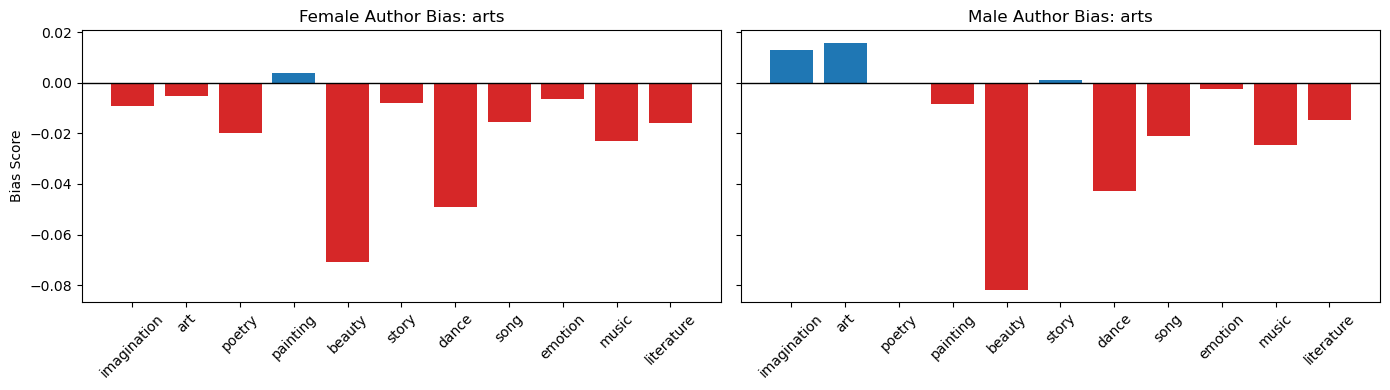


Category: professions


,Attribute_Word,Category,Female_Author_Bias,Male_Author_Bias,Delta
1,manager,professions,-0.038637,-0.005507,0.033130
2,nurse,professions,-0.070489,-0.101362,-0.030873
7,artist,professions,-0.001087,0.016903,0.017990
10,lawyer,professions,0.025328,0.014418,-0.010911
14,clerk,professions,0.004625,-0.002313,-0.006938
16,doctor,professions,0.033989,0.039840,0.005852


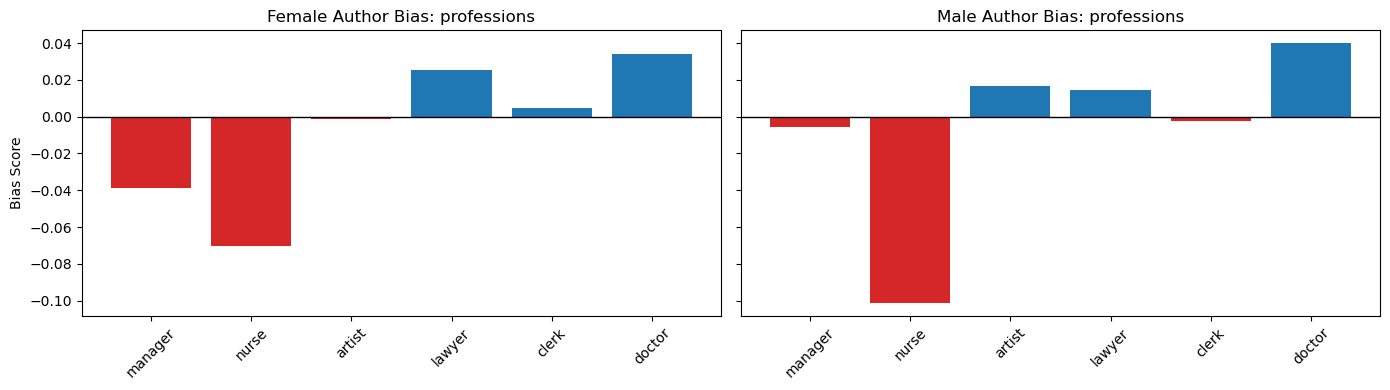


Category: science


,Attribute_Word,Category,Female_Author_Bias,Male_Author_Bias,Delta
13,reason,science,-0.009489,-0.000768,0.008721
20,science,science,0.014956,0.012060,-0.002896


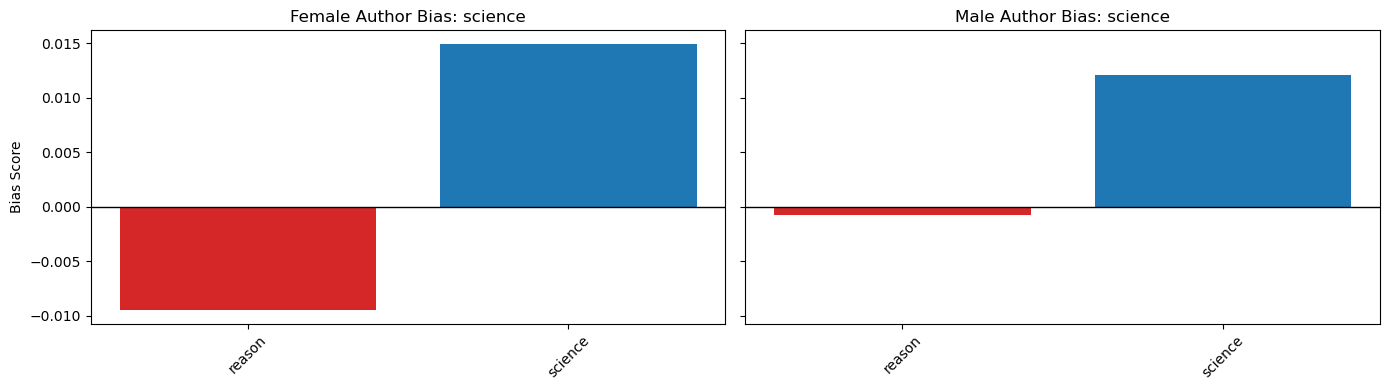


Category: stereotype_traits


,Attribute_Word,Category,Female_Author_Bias,Male_Author_Bias,Delta
3,strong,stereotype_traits,-0.006082,0.020051,0.026133
11,gentle,stereotype_traits,-0.029674,-0.040175,-0.010501
18,sensitive,stereotype_traits,-0.017561,-0.012897,0.004664
23,caring,stereotype_traits,0.001633,0.001906,0.000273
24,rational,stereotype_traits,-0.008123,-0.008346,-0.000223


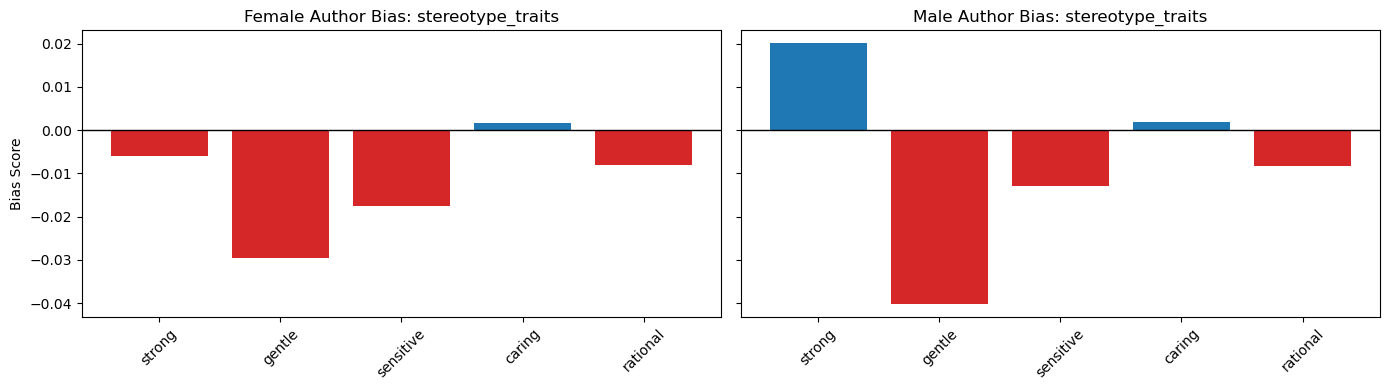

In [4]:
for category in sorted(df['Category'].unique()):
    print(f'\nCategory: {category}')
    display(df[df['Category'] == category].reindex(df[df['Category'] == category]['Delta'].abs().sort_values(ascending=False).index).head(10))
    plot_category_individual_bias(df, category)

## Top Delta Across All Categories

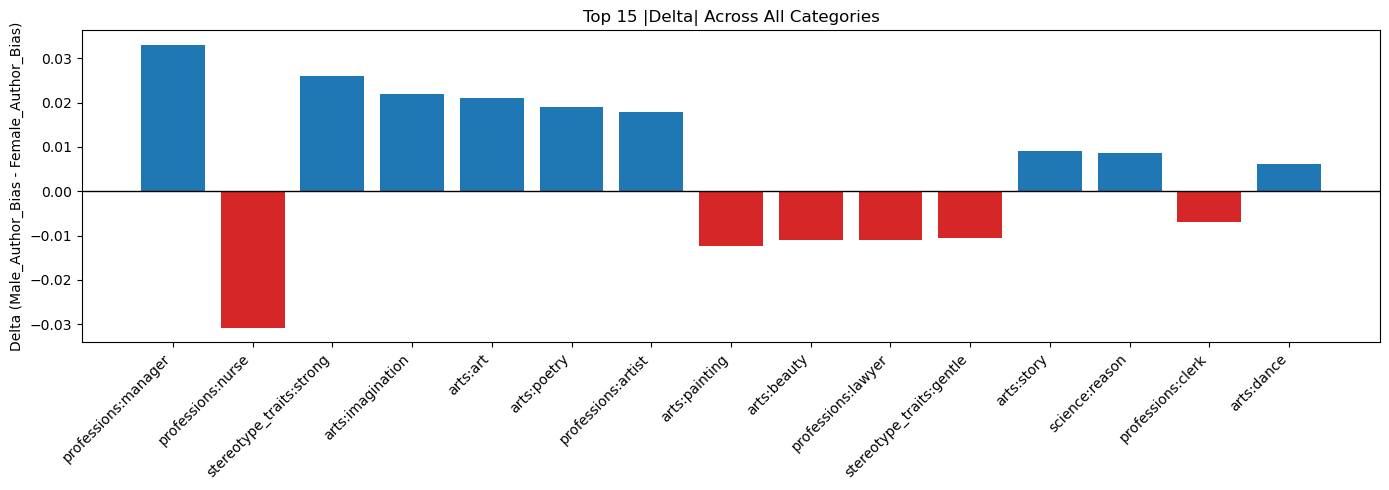

In [5]:
plot_top_overall_delta(df, top_n=15)

## Category-wise Delta Graphs


Category: arts


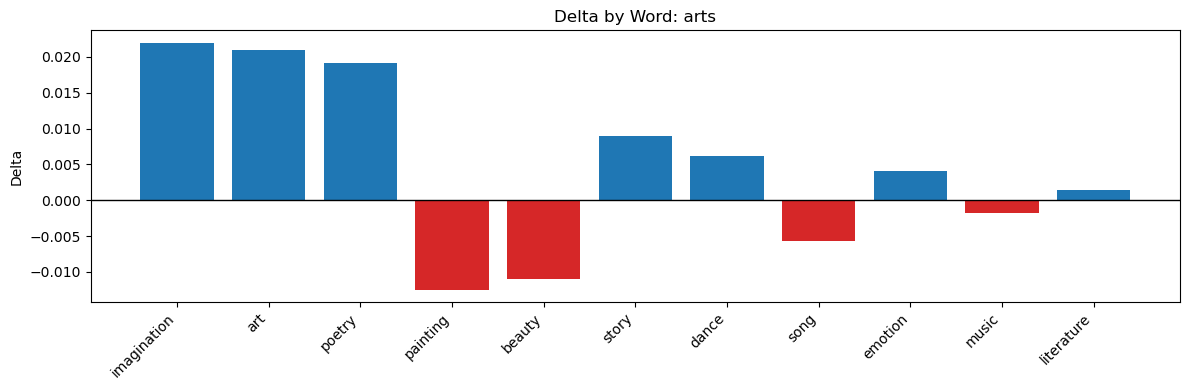


Category: professions


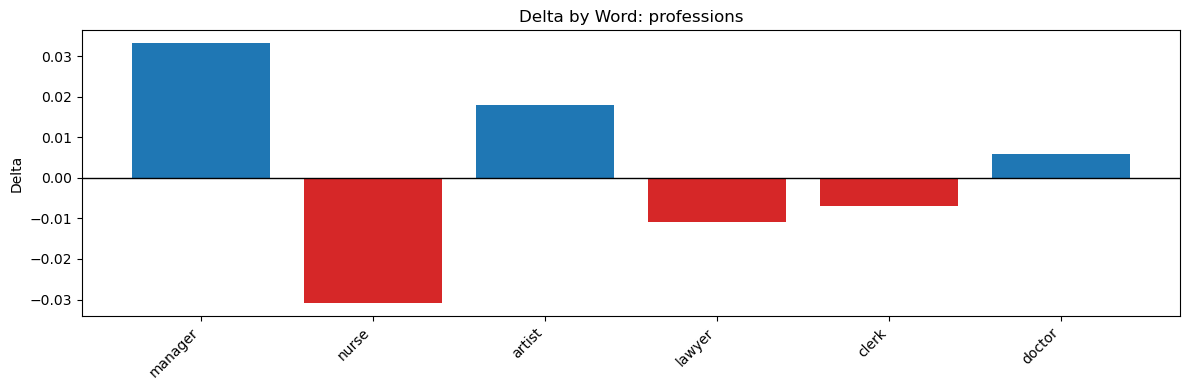


Category: science


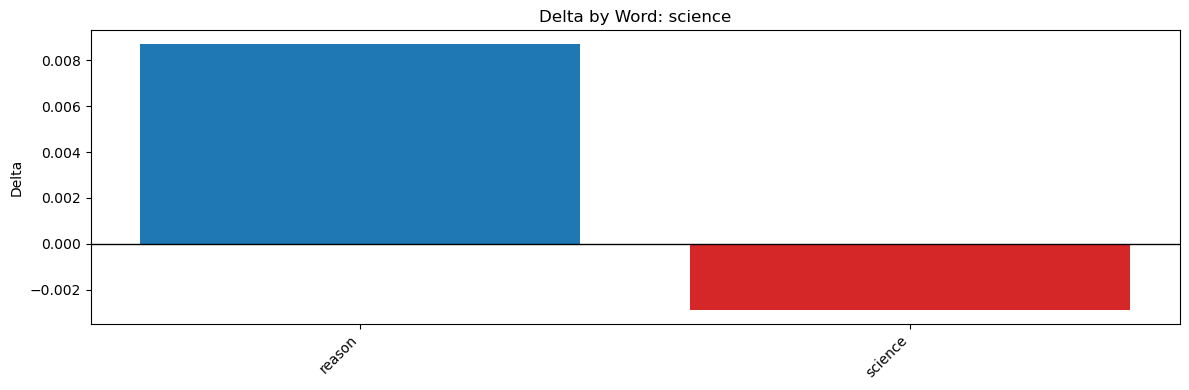


Category: stereotype_traits


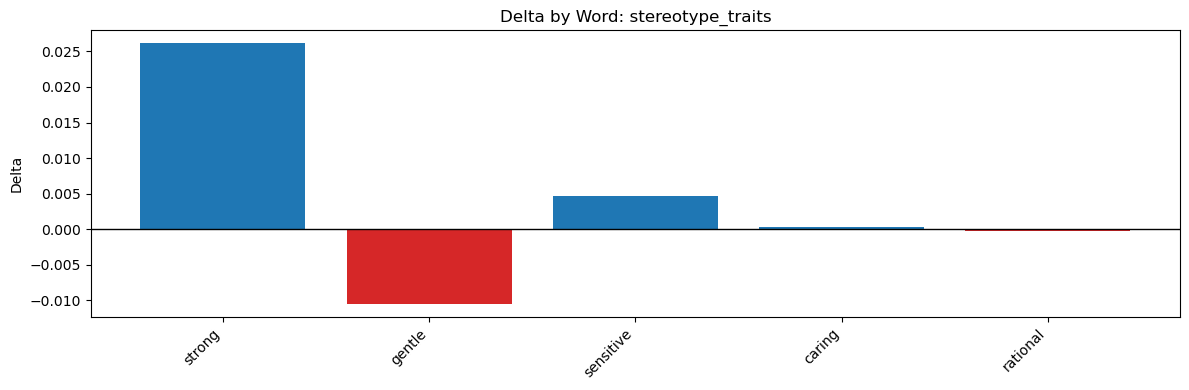

In [6]:
for category in sorted(df['Category'].unique()):
    print(f'\nCategory: {category}')
    plot_category_delta(df, category)